In [1]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath("../"))
from simulators.CA_modified import CellularAutomaton_humidity_age

# Impact of humidity on fire propagation and the function modeling the humidity-related coefficient

### Different functions used

In [2]:
def phi_flat(delta_h: float) -> float:
    return 1.0

def psi_linear(m: float) -> float:
    m = np.clip(m, 0.0, 1.0)
    return 1.0 - 0.8 * m

def psi_exp(m: float) -> float:
    m = np.clip(m, 0.0, 1.0)
    return np.exp(-2.0 * m)


def psi_power(m: float) -> float:
    m = np.clip(m, 0.0, 1.0)
    return (1.0 - m) ** 2

def psi_threshold(m: float) -> float:
    m = np.clip(m, 0.0, 1.0)
    return 1.0 if m < 0.4 else 0.2

psi_dict = {
    "linear": psi_linear,
    "exponential": psi_exp,
    "power": psi_power,
    "threshold": psi_threshold,
}

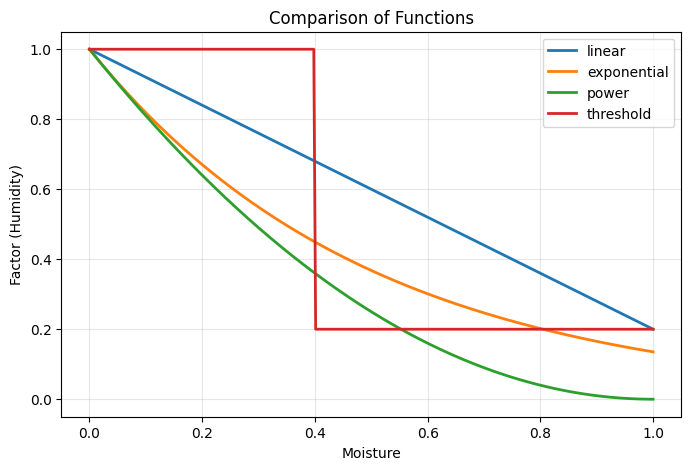

In [3]:
m_vals = np.linspace(0, 1, 300)

plt.figure(figsize=(8, 5))
for name, psi in psi_dict.items():
    plt.plot(m_vals, [psi(m) for m in m_vals], label=name, linewidth=2)

plt.xlabel("Moisture")
plt.ylabel("Factor (Humidity)")
plt.title("Comparison of Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Parameters

In [4]:
N = 100
steps = 60
display_every = 5

wind = np.ones((N, N))
heights = np.zeros((N, N))

# no wind, no height variation, no age effect
age_grid = 30 * np.ones((N, N))

start_point = [(N // 2, N // 2)]
start_state = [0.6]

### Different moisture maps

In [5]:
def uniform_moisture(N, value):
    return value * np.ones((N, N))

def left_right_moisture(N, left=0.2, right=0.8):
    moisture = np.zeros((N, N))
    moisture[:, :N // 2] = left
    moisture[:, N // 2:] = right
    return moisture

def center_wet_patch(N, background=0.2, patch=0.8, patch_size=30):
    moisture = background * np.ones((N, N))
    c = N // 2
    h = patch_size // 2
    moisture[c-h:c+h, c-h:c+h] = patch
    return moisture

def random_moisture(N, low=0.1, high=0.9, block=10, seed=0):
    rng = np.random.default_rng(seed)
    coarse = rng.uniform(low, high, size=(N // block + 1, N // block + 1))
    moisture = np.kron(coarse, np.ones((block, block)))
    return moisture[:N, :N]


moisture_maps = {
    "Uniform dry": uniform_moisture(N, 0.1),
    "Uniform wet": uniform_moisture(N, 0.8),
    "Left dry / right wet": left_right_moisture(N),
    "Central wet patch": center_wet_patch(N),
    "Random humidity": random_moisture(N),
}

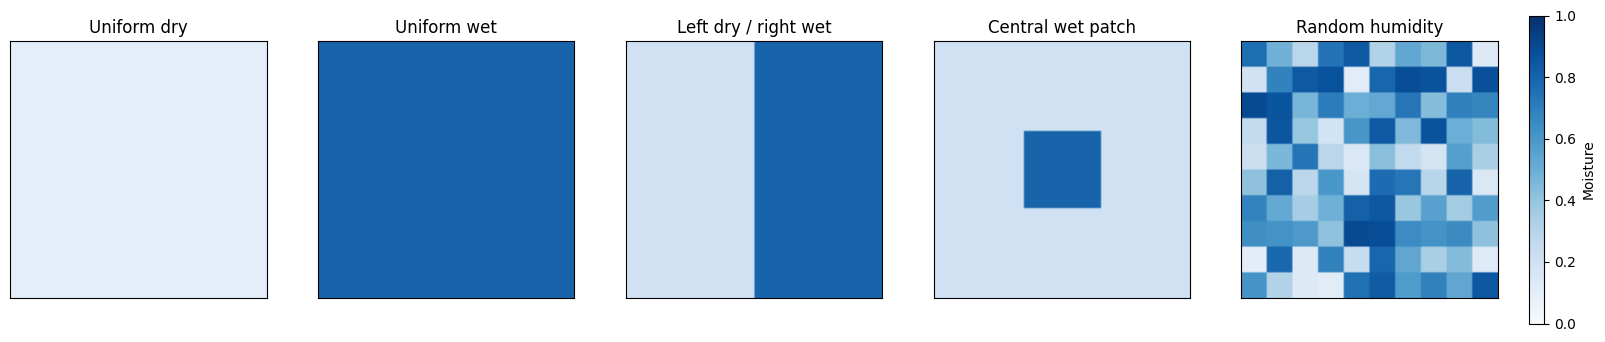

In [7]:
fig, axes = plt.subplots(1, len(moisture_maps), figsize=(4 * len(moisture_maps), 4))

for ax, (name, moisture) in zip(axes, moisture_maps.items()):
    im = ax.imshow(moisture, cmap="Blues", vmin=0, vmax=1, origin="lower")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="Moisture")
plt.show()

# Simulation

In [10]:
def run_and_plot(psi, psi_name, moisture_grid, moisture_name):
    CA = CellularAutomaton_humidity_age(
        grid_height=N,
        grid_width=N,
        wind_grid=wind,
        height_grid=heights,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=phi_flat,
        psi=psi,
        t_max=30.0,
        p_max=1.0,
        alpha_age=2.0,
    )

    CA.initialize_ignition(start_point, start_state)

    snapshots = []
    for step in range(steps + 1):
        if step % display_every == 0:
            snapshots.append((step, CA.get_state().copy()))
        if step < steps:
            CA.evolve(use_age=True, use_moisture=True)

    fig1, ax1 = plt.subplots(figsize=(5, 5))
    im1 = ax1.imshow(moisture_grid, cmap="Blues", vmin=0, vmax=1, origin="lower")
    ax1.set_title(f"{moisture_name} - {psi_name} - humidity map")
    ax1.set_xticks([])
    ax1.set_yticks([])
    fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Moisture")
    plt.show()

   
    n = len(snapshots)
    fig2, axes = plt.subplots(1, n, figsize=(3.5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (step, state) in zip(axes, snapshots):
        im2 = ax.imshow(state, cmap="magma", vmin=0, vmax=1, origin="lower")
        ax.set_title(f"Step {step}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig2.colorbar(im2, ax=axes, fraction=0.02, pad=0.04, label="Fire intensity")
    fig2.suptitle(f"{moisture_name} - {psi_name}", fontsize=14)
    plt.show()

# Visualisation

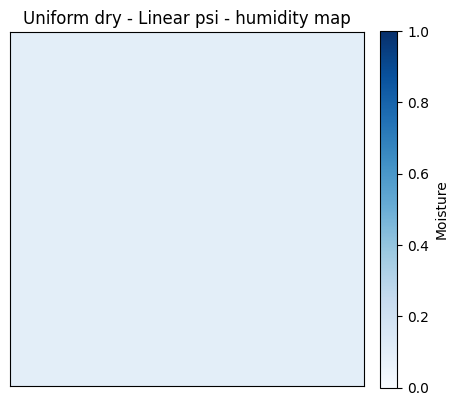

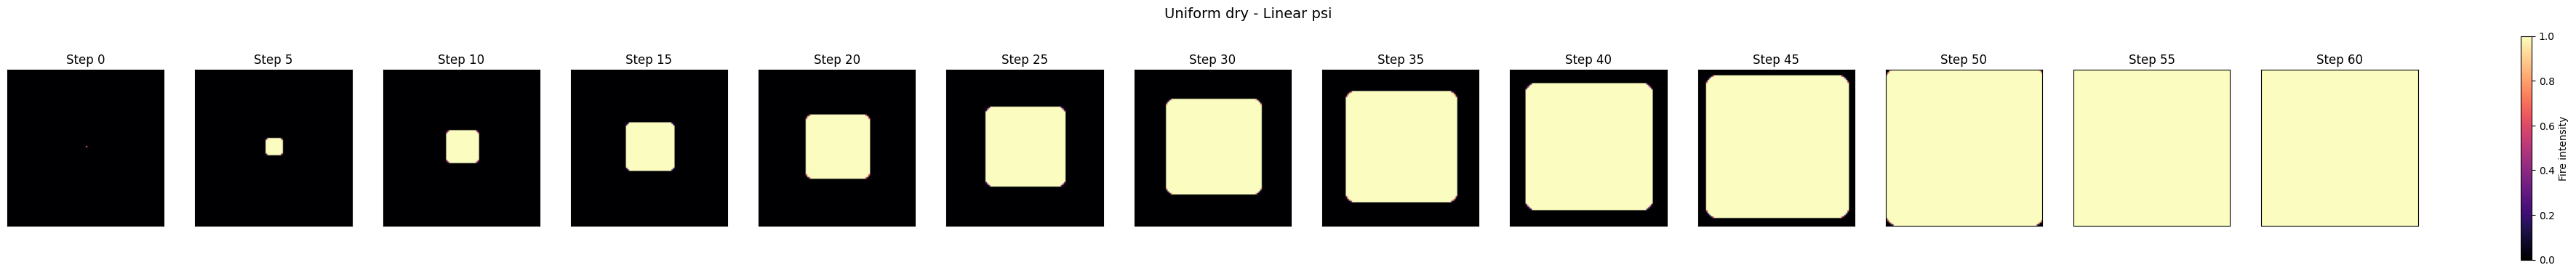

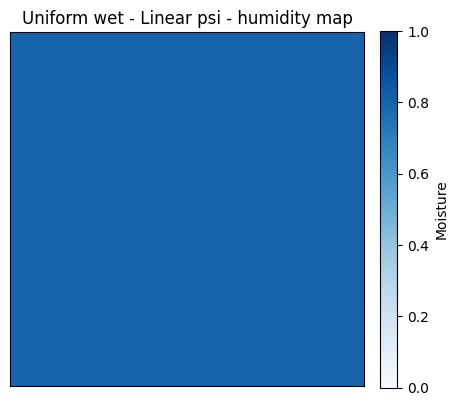

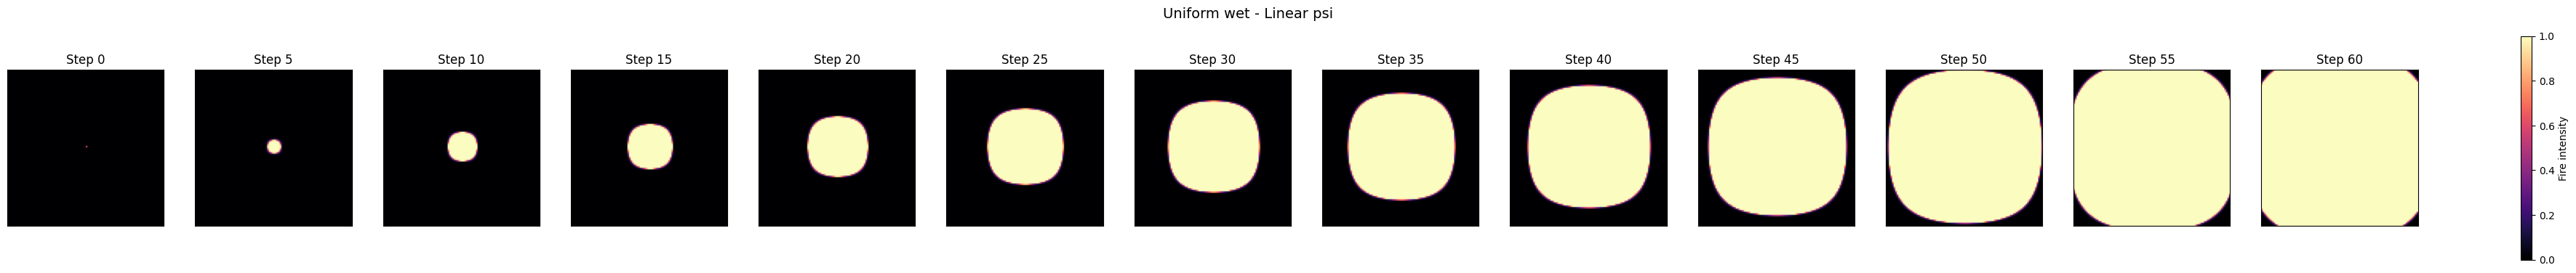

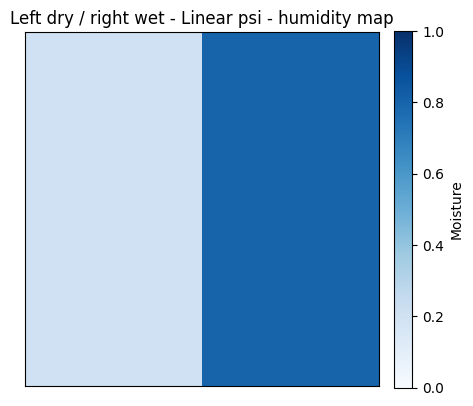

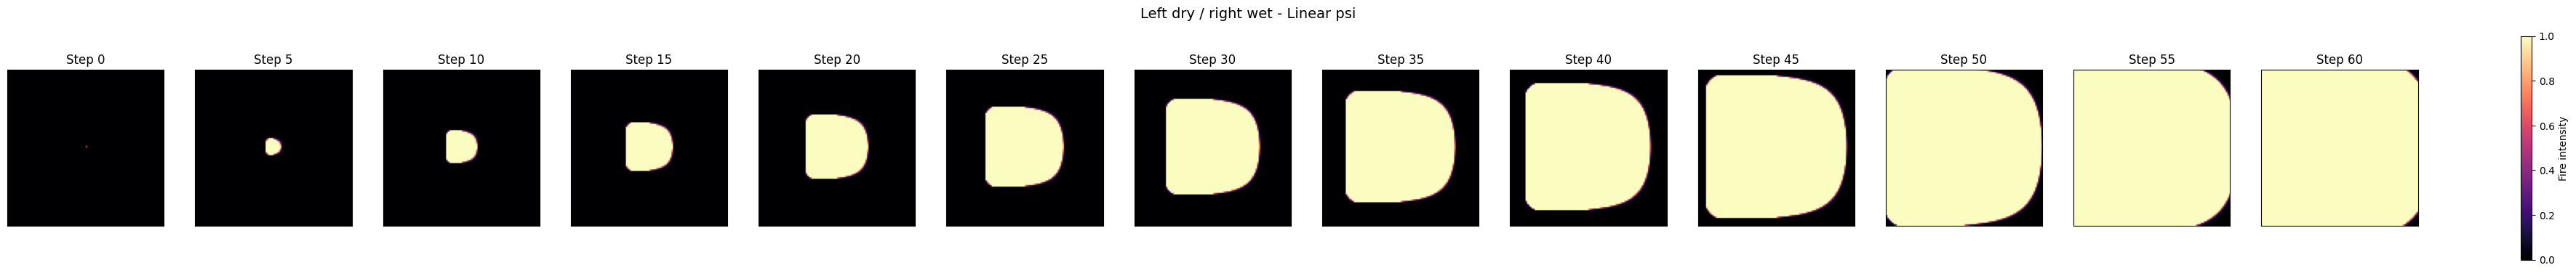

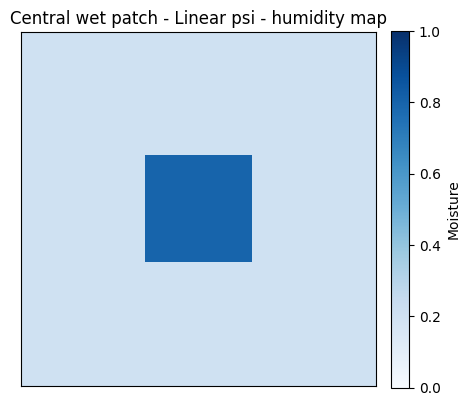

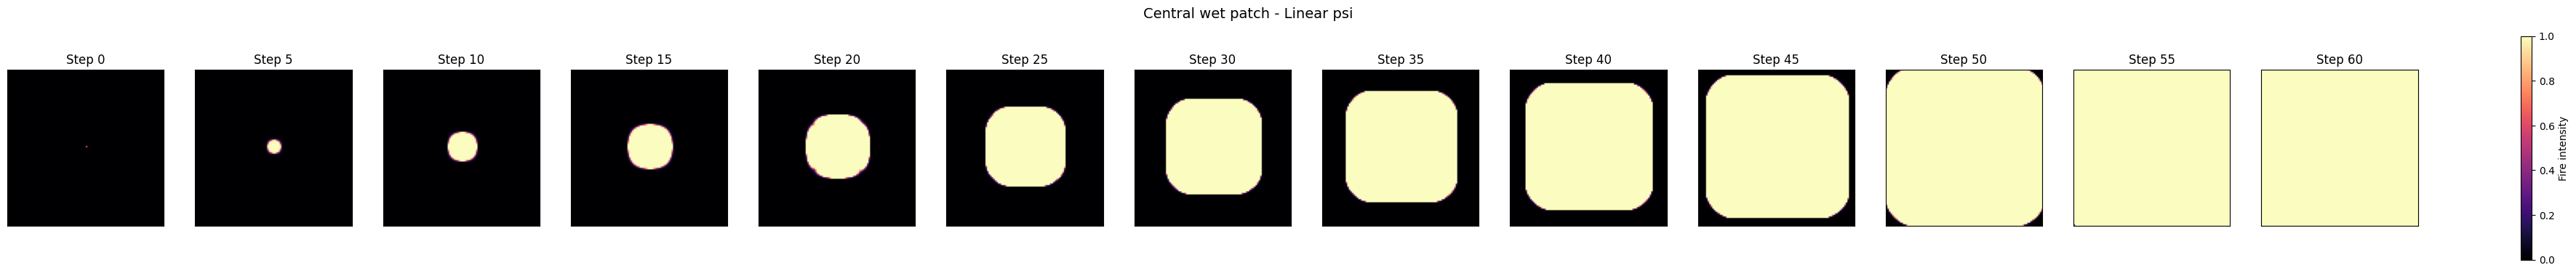

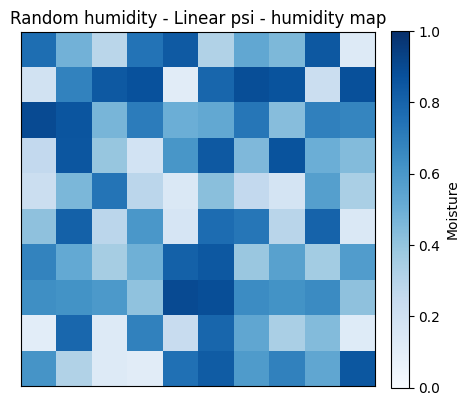

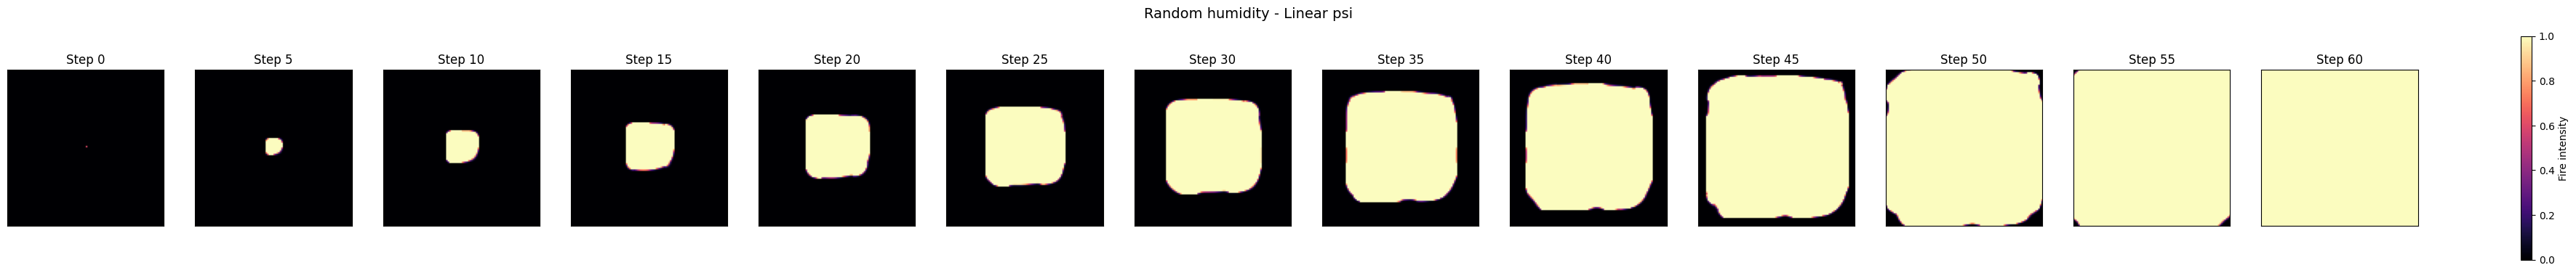

In [11]:
for moisture_name, moisture_grid in moisture_maps.items():
    run_and_plot(psi_linear, "Linear psi", moisture_grid, moisture_name)

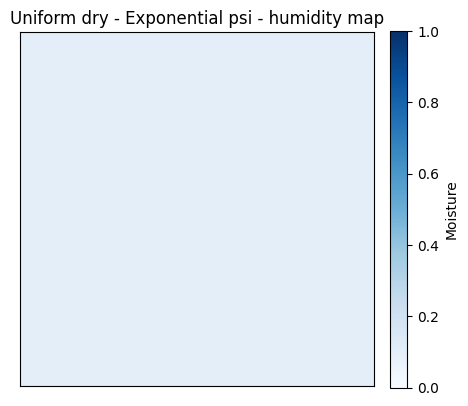

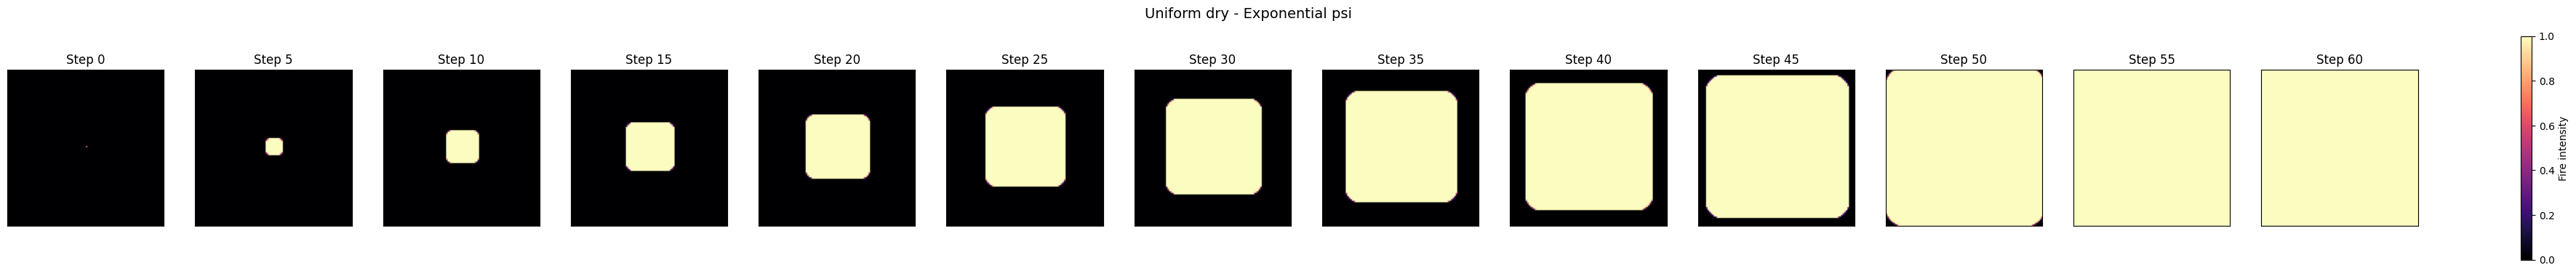

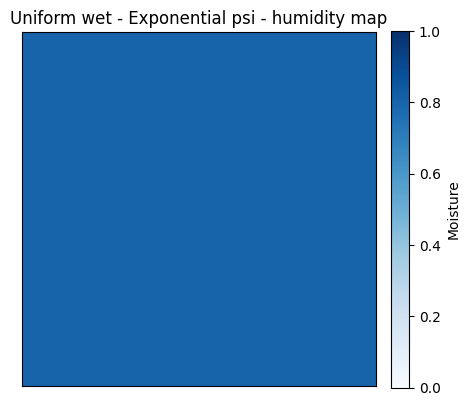

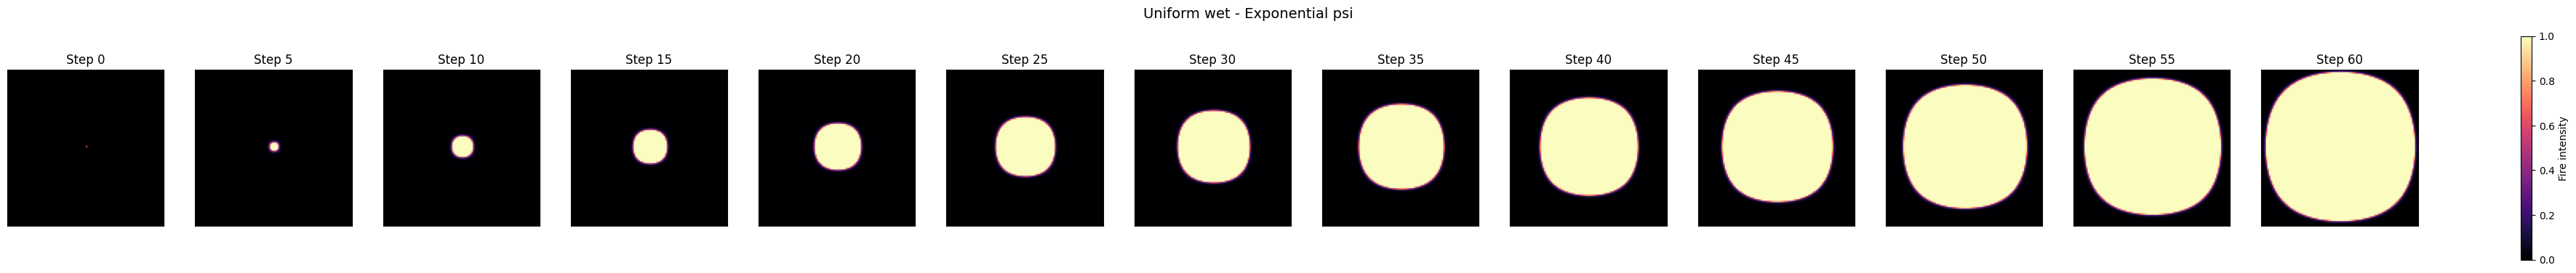

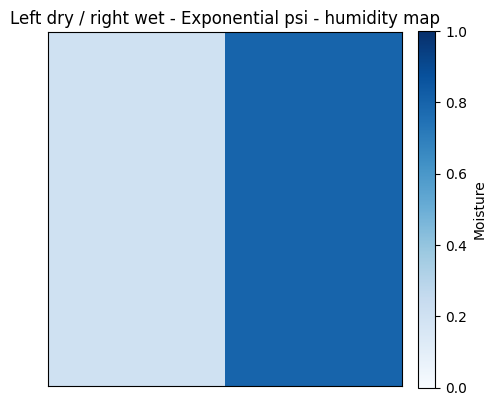

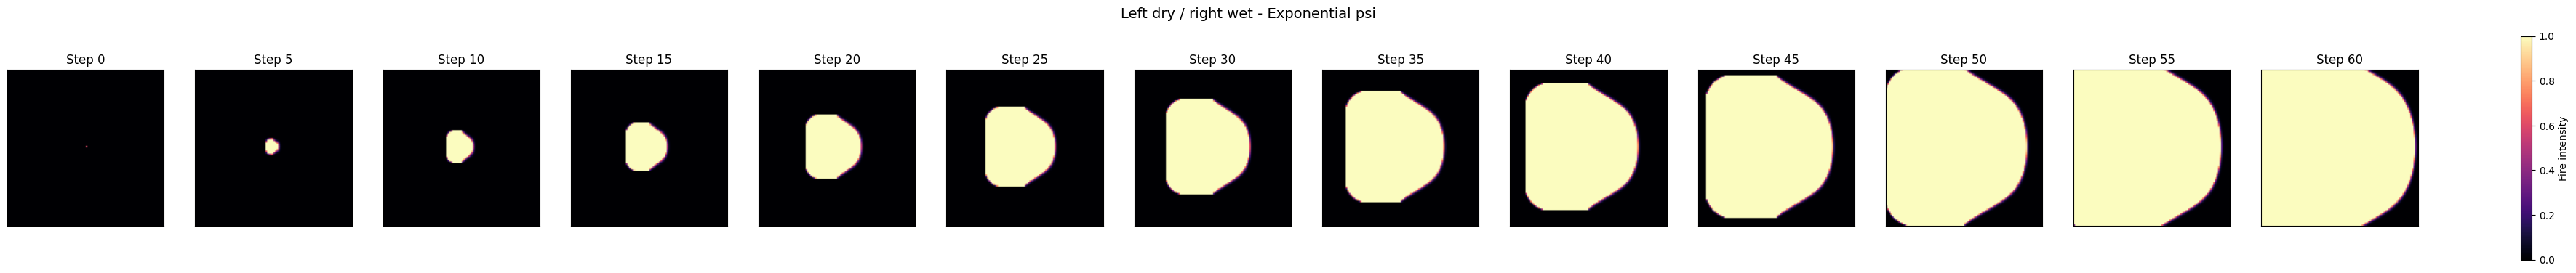

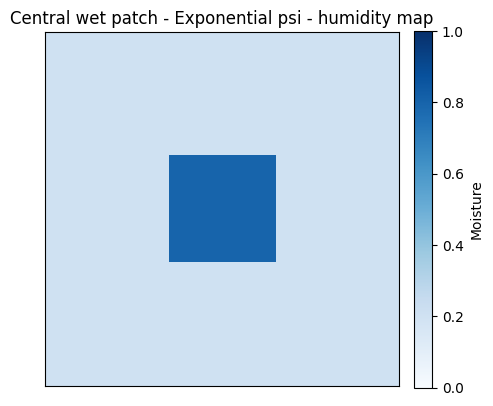

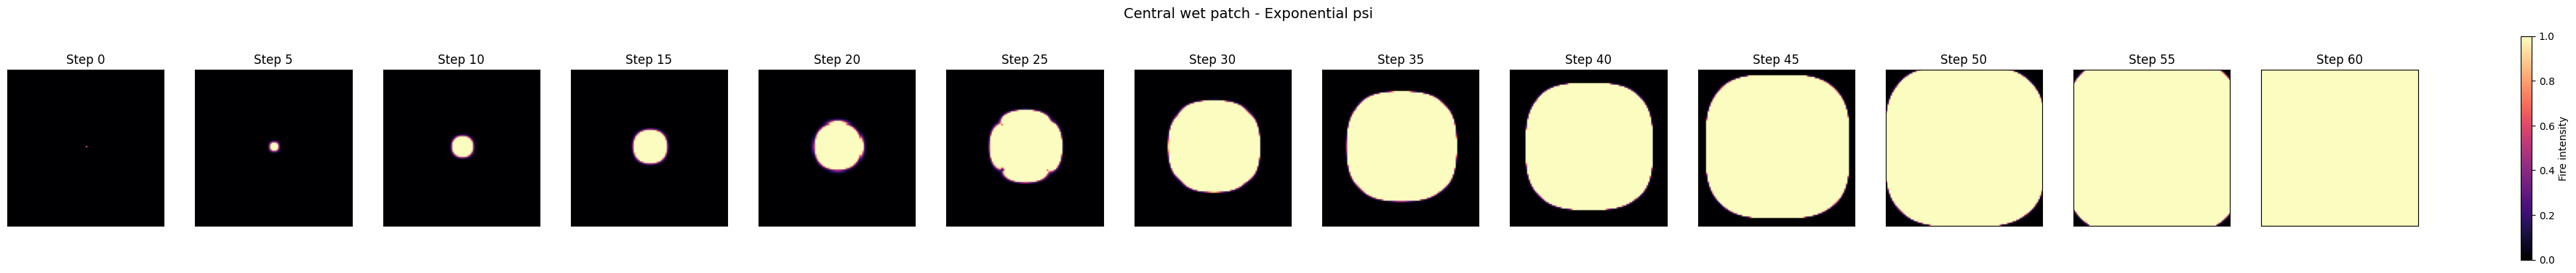

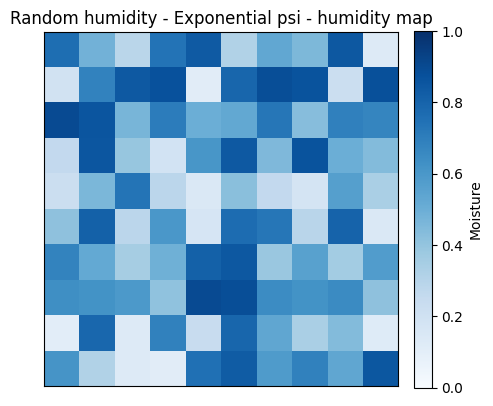

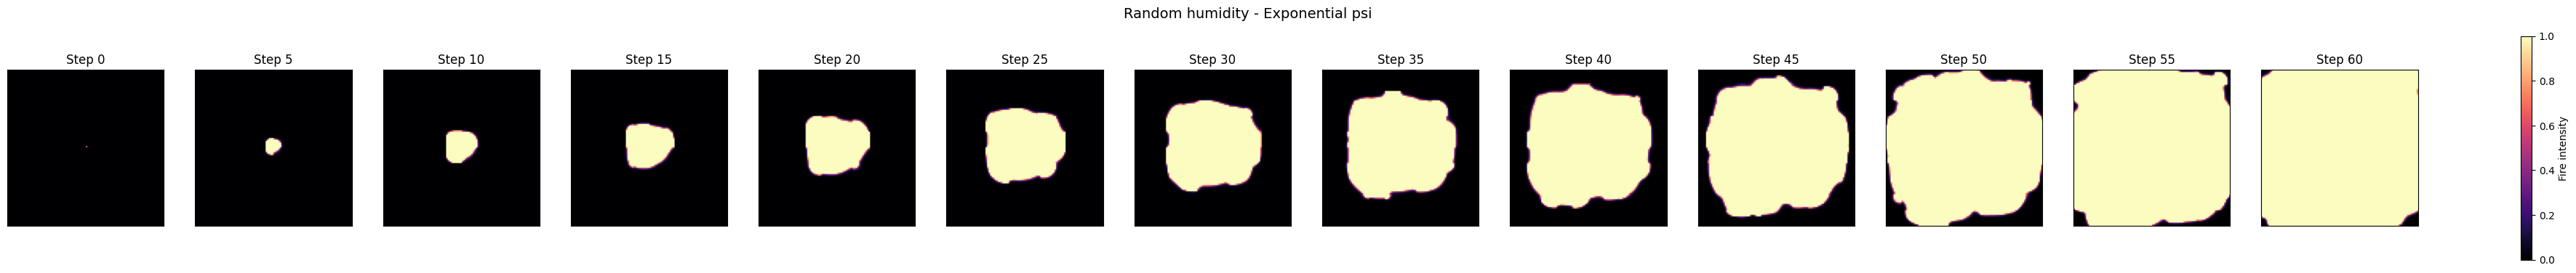

In [12]:
for moisture_name, moisture_grid in moisture_maps.items():
    run_and_plot(psi_exp, "Exponential psi", moisture_grid, moisture_name)

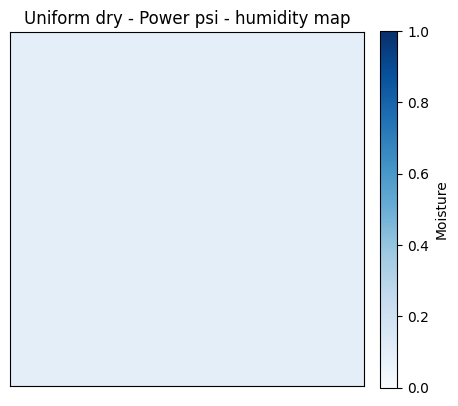

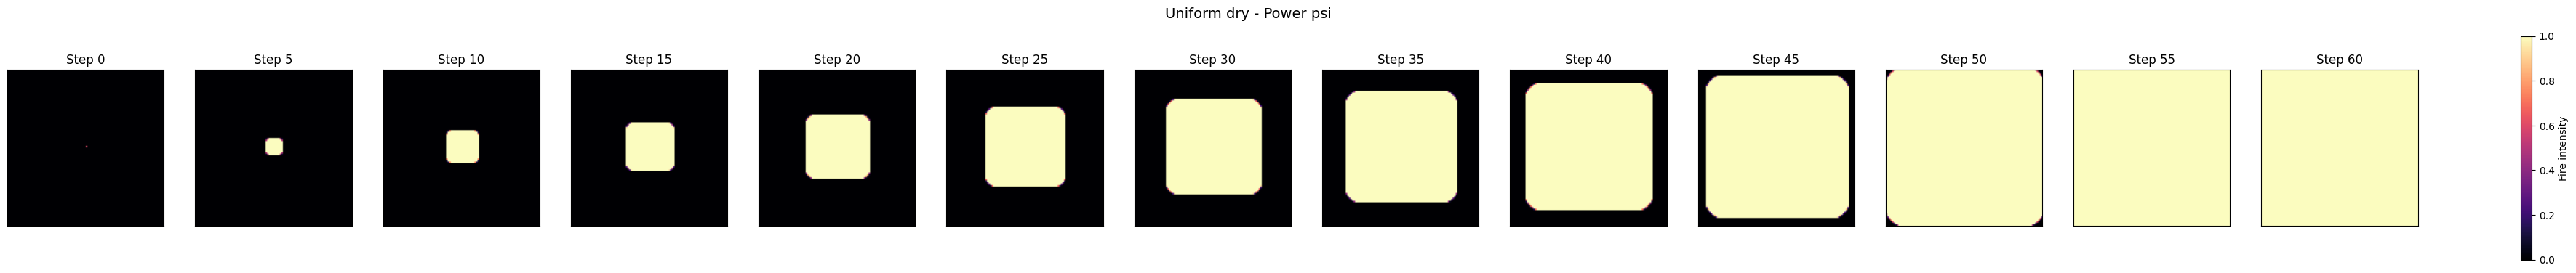

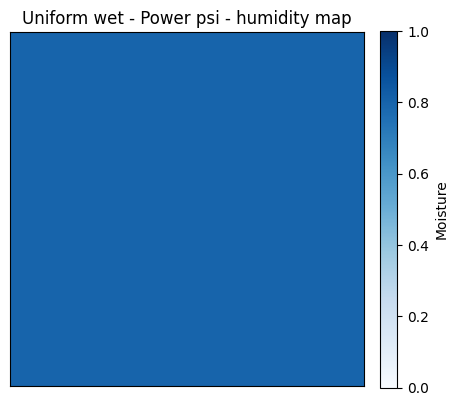

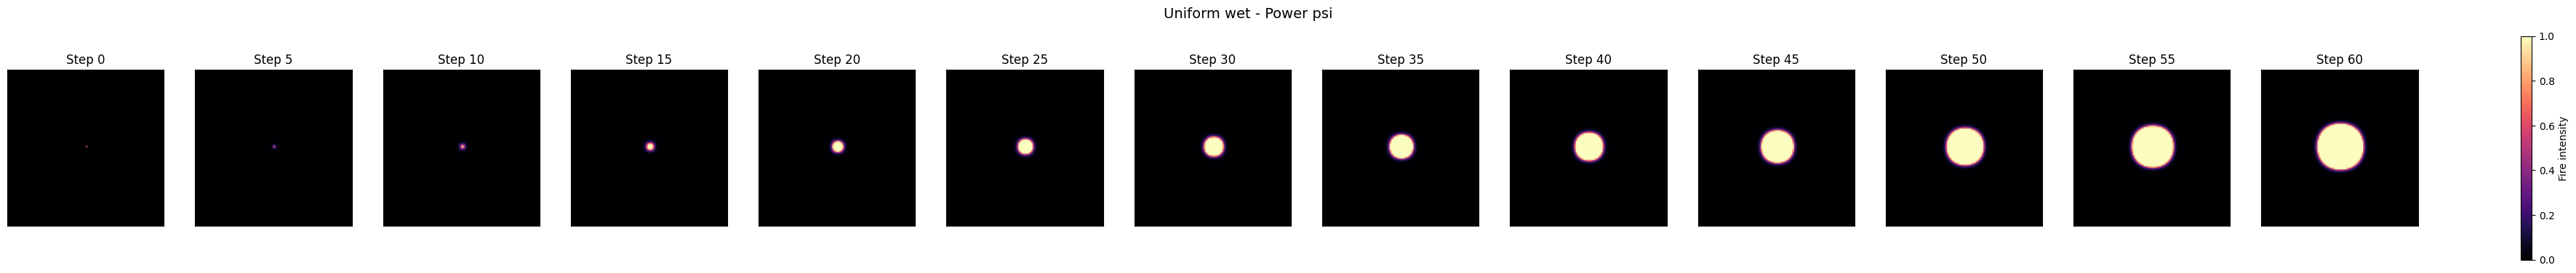

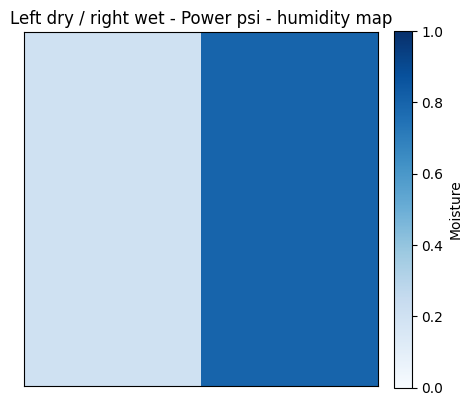

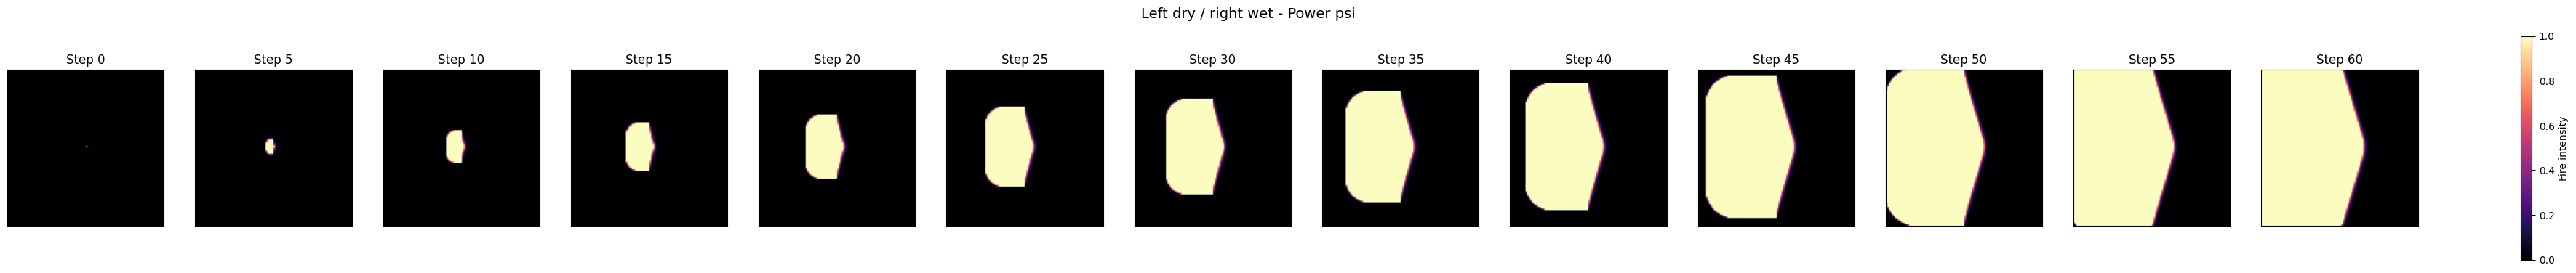

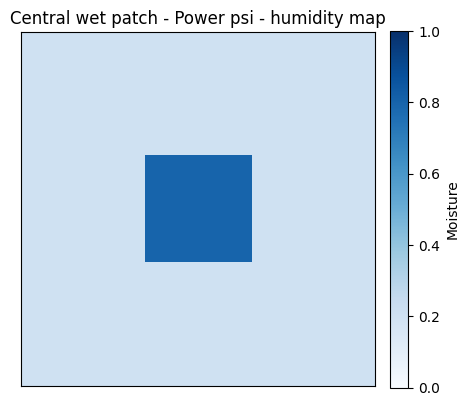

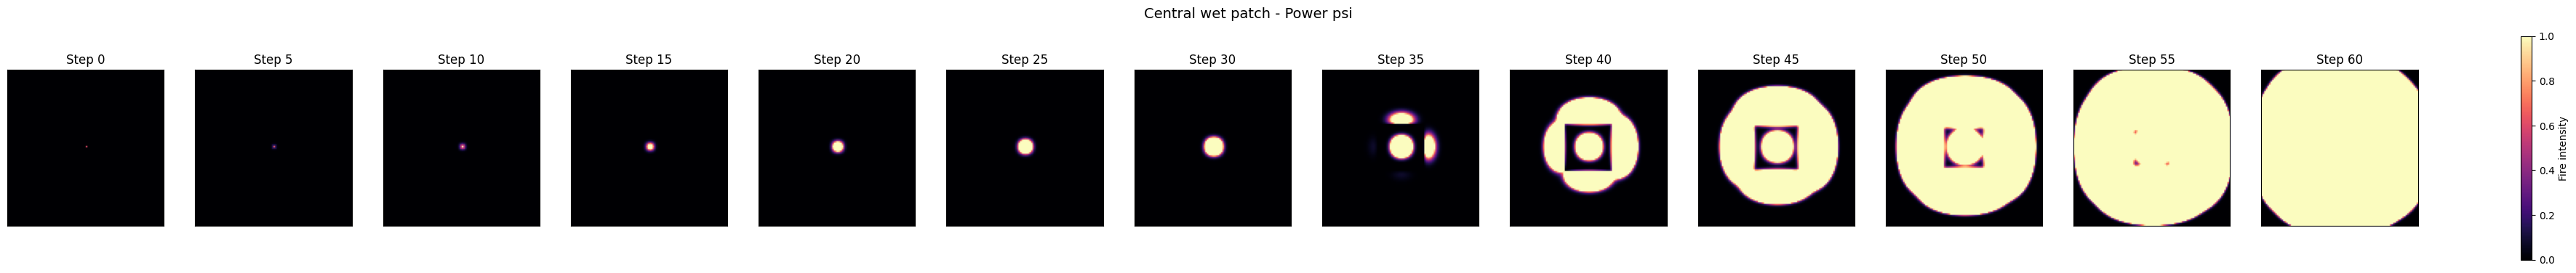

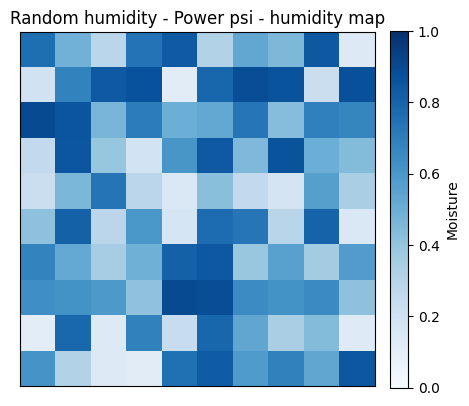

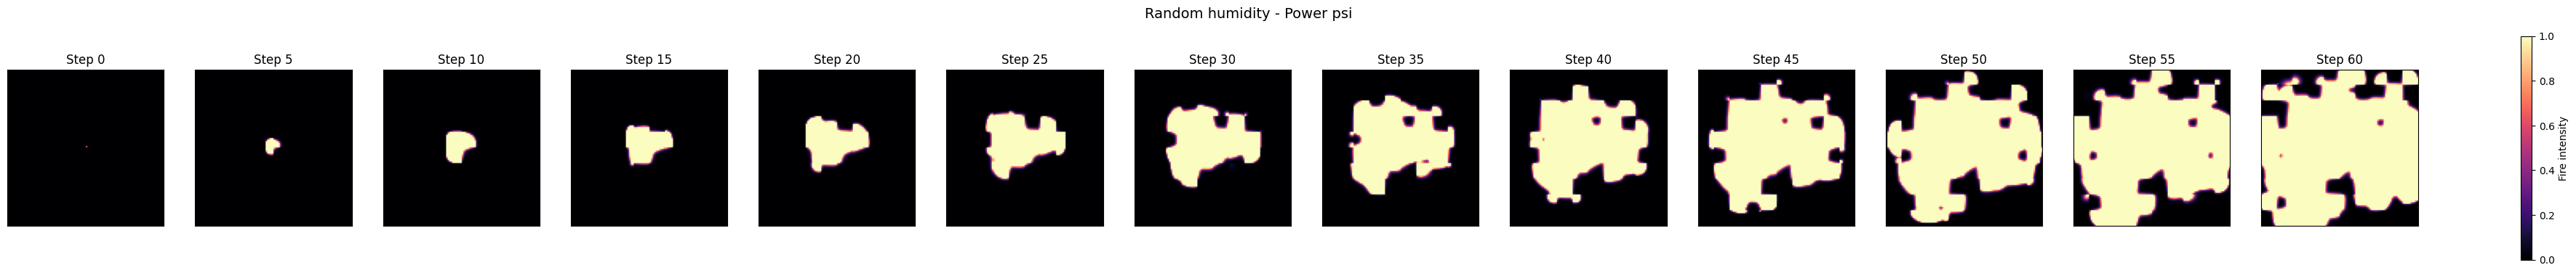

In [13]:
for moisture_name, moisture_grid in moisture_maps.items():
    run_and_plot(psi_power, "Power psi", moisture_grid, moisture_name)

### Burned area across time

In [15]:
def burned_area(state_grid):
    return np.sum(state_grid)

In [16]:
def run_burned_area_curve(psi, moisture_grid):
    CA = CellularAutomaton_humidity_age(
        grid_height=N,
        grid_width=N,
        wind_grid=wind,
        height_grid=heights,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=phi_flat,
        psi=psi,
        t_max=30.0,
        p_max=1.0,
        alpha_age=2.0,
    )

    CA.initialize_ignition(start_point, start_state)

    areas = [burned_area(CA.get_state())]

    for _ in range(steps):
        CA.evolve(use_age=True, use_moisture=True)
        areas.append(burned_area(CA.get_state()))

    return np.arange(steps + 1), np.array(areas)

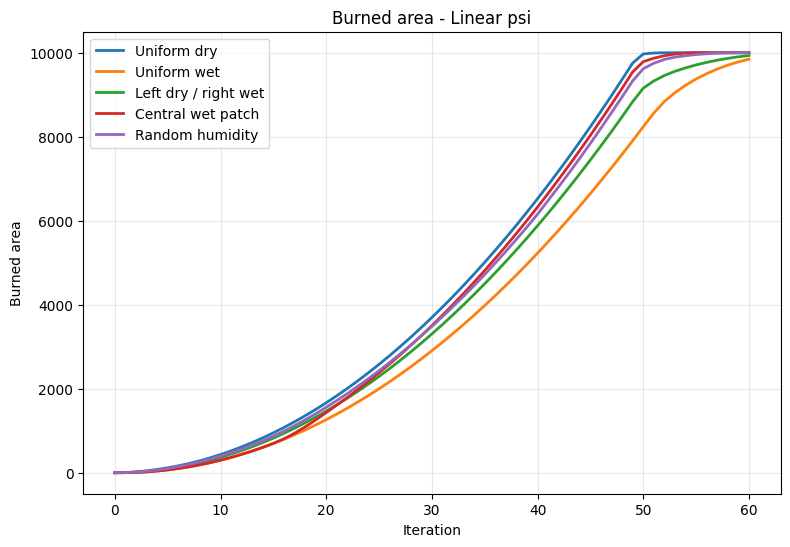

In [17]:
plt.figure(figsize=(9, 6))

for moisture_name, moisture_grid in moisture_maps.items():
    t, area = run_burned_area_curve(psi_linear, moisture_grid)
    plt.plot(t, area, linewidth=2, label=moisture_name)

plt.xlabel("Iteration")
plt.ylabel("Burned area")
plt.title("Burned area - Linear psi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

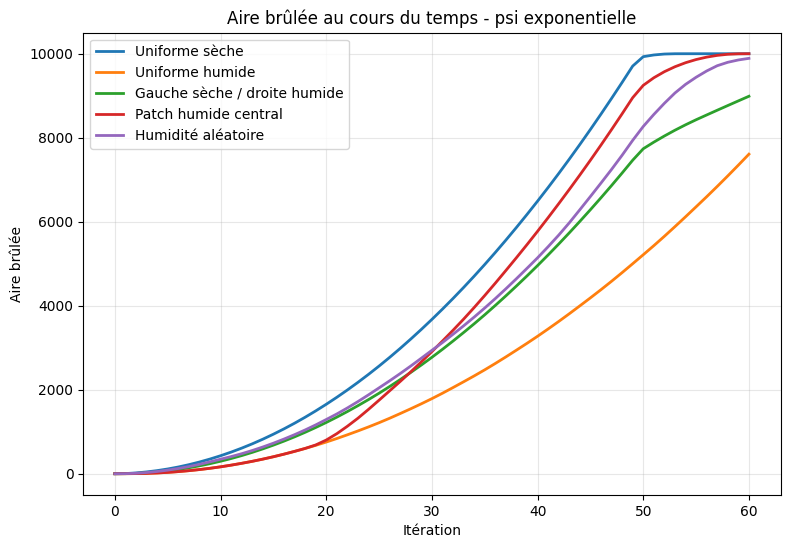

In [ ]:
plt.figure(figsize=(9, 6))

for moisture_name, moisture_grid in moisture_maps.items():
    t, area = run_burned_area_curve(psi_exp, moisture_grid)
    plt.plot(t, area, linewidth=2, label=moisture_name)

plt.xlabel("Iteration")
plt.ylabel("Burned area")
plt.title("Burned area - Exponential psi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

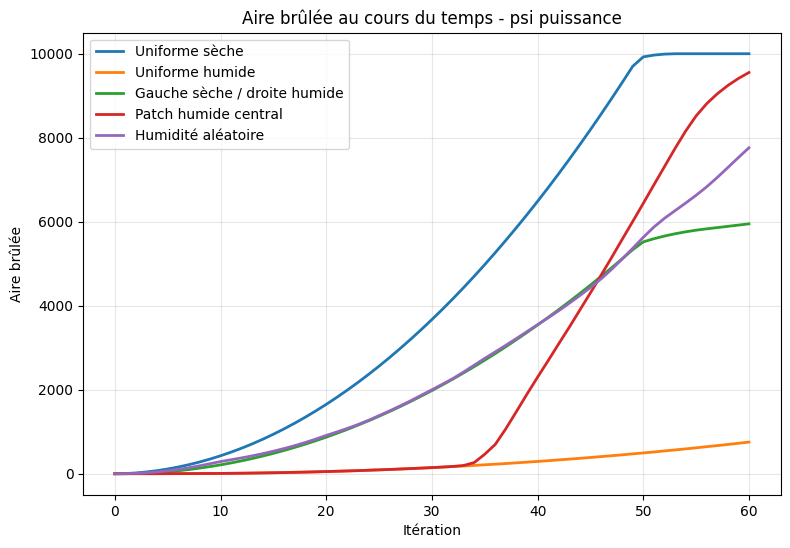

In [ ]:
plt.figure(figsize=(9, 6))

for moisture_name, moisture_grid in moisture_maps.items():
    t, area = run_burned_area_curve(psi_power, moisture_grid)
    plt.plot(t, area, linewidth=2, label=moisture_name)

plt.xlabel("Iteration")
plt.ylabel("Burned area")
plt.title("Burned area - Power psi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()